# Diabetes Dataset Analysis

This notebook performs a comprehensive analysis of the `diabetes.csv` dataset, covering the following stages:

1.  **Understand Data Structure**: Examine basic information, data types, and initial missing values.
2.  **Clean and Preprocess Data**: Address implicit missing values (zeros), impute them, and handle outliers.
3.  **Exploratory Data Analysis (EDA)**: Conduct descriptive statistics, correlation analysis, and initial visualizations.
4.  **Visualize Key Features**: Create specific visualizations for important variables to gain deeper insights.
5.  **Summarize Findings**: Provide a summary of observations and suggest potential next steps.

## Understand Data Structure

### Subtask:
Display basic information about the `diabetes.csv` dataset, such as the shape (number of rows and columns), data types of each column, and a summary of missing values. This helps in understanding the overall structure and quality of the data.

In [19]:
df = pd.read_csv('/content/diabetes.csv')
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# Display DataFrame shape
print(f"DataFrame shape: {df.shape}")

# Display basic information about the DataFrame
print("\nDataFrame Info:")
df.info()

# Display the count of missing values for each column
print("\nMissing values (initial check):")
print(df.isnull().sum())

DataFrame shape: (768, 9)

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Missing values (initial check):
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI           

## Clean and Preprocess Data

### Subtask:
Perform initial data cleaning steps for the `diabetes.csv` dataset. This involves handling implicit missing values (represented as 0s), correcting inconsistencies, converting data types if necessary, and identifying/addressing outliers.

The `df.info()` output shows no explicit missing values, but it's common in medical datasets for 0 values in certain columns to represent missing or unrecorded data, rather than actual zero measurements. Biologically, values like 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', and 'BMI' cannot be zero. Therefore, I will replace these 0s with `np.nan` and then impute them using the median, which is more robust to outliers than the mean.

In [ ]:
import numpy as np

# Columns where 0 values are biologically implausible and likely represent missing data
columns_with_zeros_as_nan = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace 0s with NaN in the identified columns
df[columns_with_zeros_as_nan] = df[columns_with_zeros_as_nan].replace(0, np.nan)

# Display the count of missing values after replacement
print("Missing values after replacing 0s with NaN:")
print(df.isnull().sum())

Missing values after replacing 0s with NaN:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


Now that the implicit zeros have been converted to `NaN`, I will impute these missing values using the median of each respective column. The median is chosen over the mean because it is less sensitive to outliers, which are common in medical data.

In [ ]:
for column in columns_with_zeros_as_nan:
    df[column] = df[column].fillna(df[column].median())

# Verify that there are no more missing values
print("Missing values after median imputation:")
print(df.isnull().sum())

Missing values after median imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


After imputing missing values, it's good practice to check the descriptive statistics again to see the impact of these changes and to identify any potential outliers. I will display the descriptive statistics and then visualize distributions with box plots to identify outliers.

In [ ]:
print("Descriptive statistics after imputation:")
print(df.describe())

Descriptive statistics after imputation:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  121.656250      72.386719      29.108073  140.671875   
std       3.369578   30.438286      12.096642       8.791221   86.383060   
min       0.000000   44.000000      24.000000       7.000000   14.000000   
25%       1.000000   99.750000      64.000000      25.000000  121.500000   
50%       3.000000  117.000000      72.000000      29.000000  125.000000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    32.455208                  0.471876   33.240885    0.348958  
std      6.875177                  0.331329   11.760232    0.476

To visually identify potential outliers and understand the distribution of each numerical feature, box plots are highly effective. This step will generate box plots for all numerical columns to visualize their distributions and highlight any extreme values that might be considered outliers.

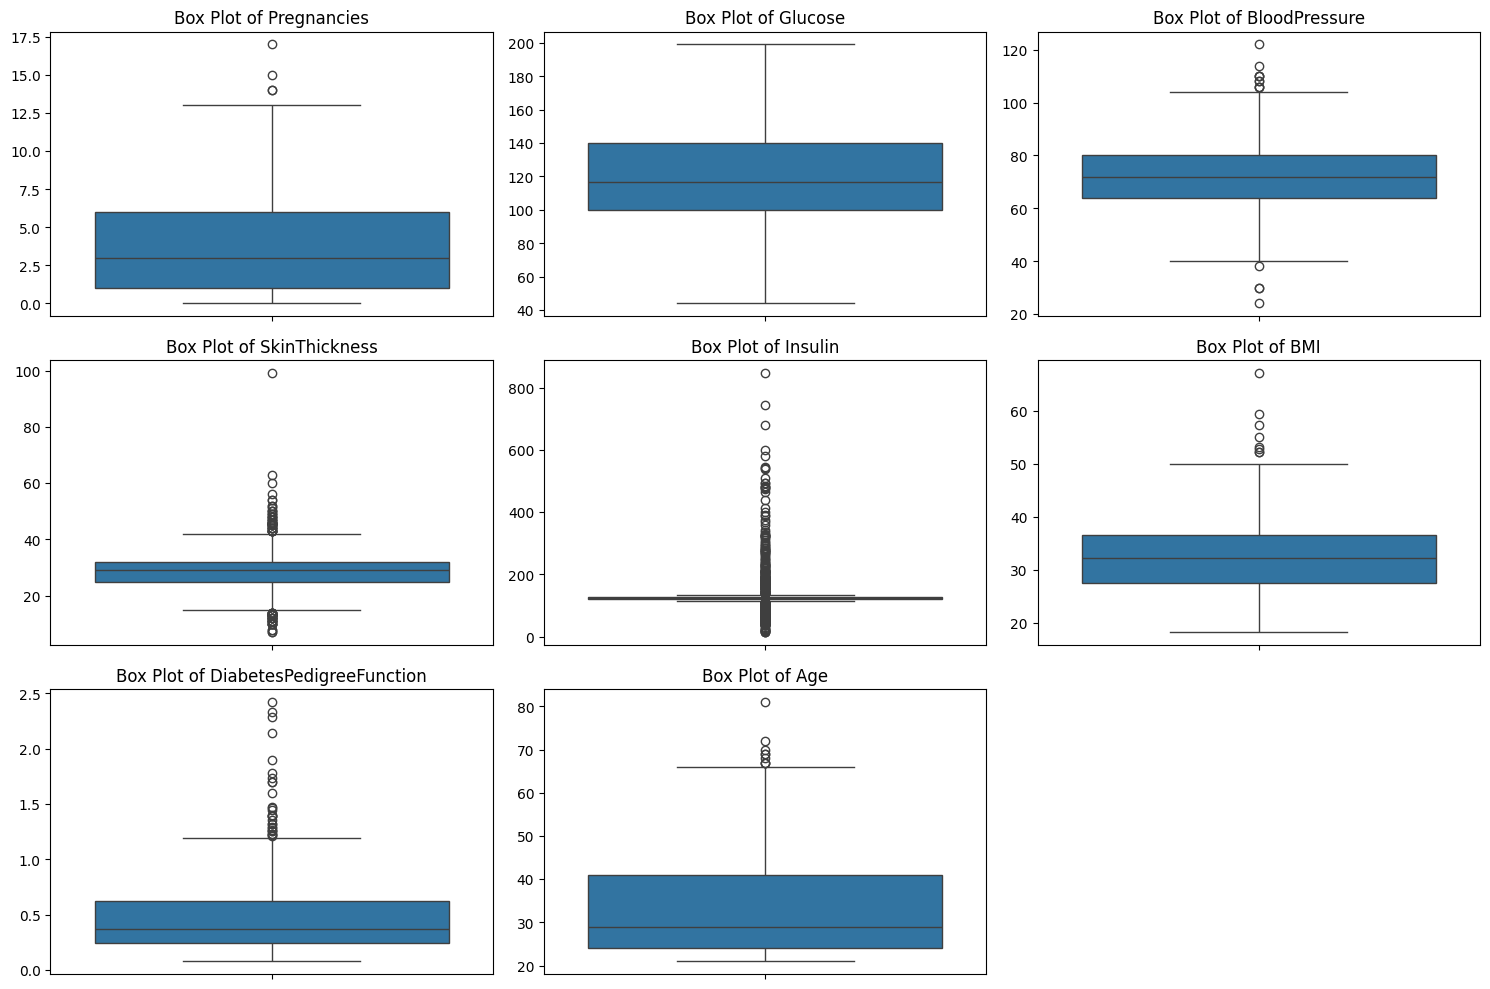

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get all numerical columns (excluding 'Outcome' as it's the target variable)
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'Outcome' in numerical_cols:
    numerical_cols.remove('Outcome')

# Set up the matplotlib figure and axes
plt.figure(figsize=(15, 10))

# Create box plots for each numerical column
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1)  # Adjust subplot grid as needed based on number of columns
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel('') # Remove y-label to avoid clutter

plt.tight_layout()
plt.show()

The box plots indicate the presence of outliers in several features. To handle these, I will use the Interquartile Range (IQR) method to cap the outliers. This approach replaces values beyond a certain range (defined by IQR) with the upper or lower bounds, thus mitigating their impact without removing data points entirely.

In [ ]:
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
    return df

# Apply outlier capping to numerical columns (excluding 'Outcome')
for col in numerical_cols:
    df = cap_outliers_iqr(df, col)

print("Descriptive statistics after outlier capping:")
print(df.describe())

Descriptive statistics after outlier capping:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.837240  121.656250      72.358073      28.866536  124.691081   
std       3.344157   30.438286      11.697097       7.442353    7.913595   
min       0.000000   44.000000      40.000000      14.500000  112.875000   
25%       1.000000   99.750000      64.000000      25.000000  121.500000   
50%       3.000000  117.000000      72.000000      29.000000  125.000000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      13.500000  199.000000     104.000000      42.500000  135.875000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    32.393359                  0.458914   33.199870    0.348958  
std      6.667471                  0.285596   11.628404    

## Exploratory Data Analysis (EDA)

### Subtask:
Conduct exploratory data analysis on the `diabetes.csv` dataset to uncover patterns, relationships, and insights. This can involve descriptive statistics, correlation analysis, and initial visualizations (e.g., histograms, scatter plots) for key medical features related to diabetes.

I will calculate the correlation matrix for all numerical features and visualize it using a heatmap to identify linear relationships between variables.

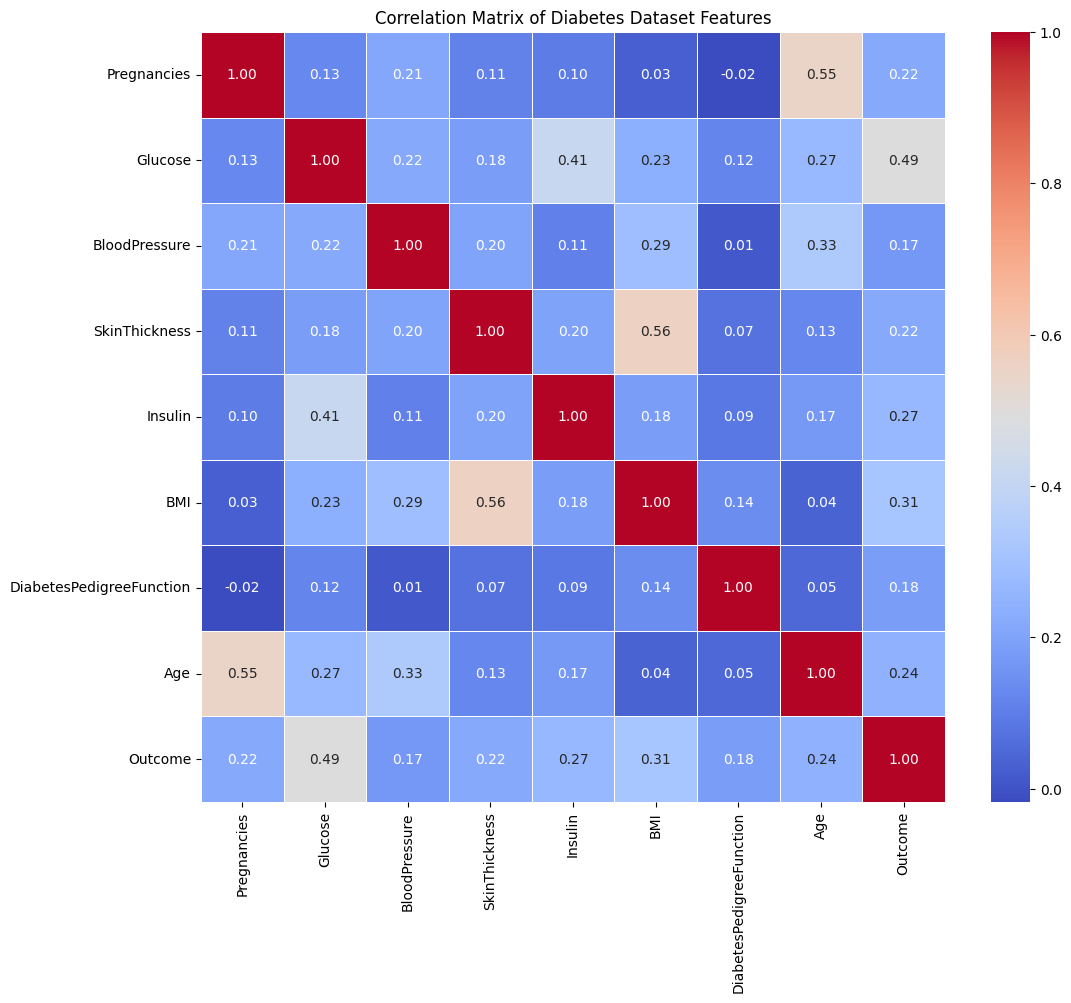

In [ ]:
# Calculate the correlation matrix
corr_matrix = df.corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Diabetes Dataset Features')
plt.show()

Next, I will visualize the distribution of the target variable, 'Outcome', using a count plot. This will show the proportion of diabetic and non-diabetic individuals in the dataset. Additionally, I will create histograms for all numerical features to understand their distributions.

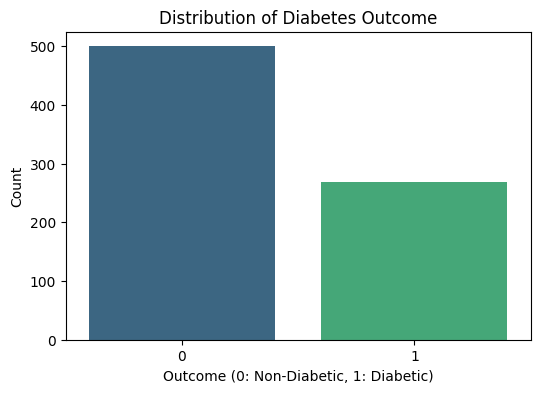

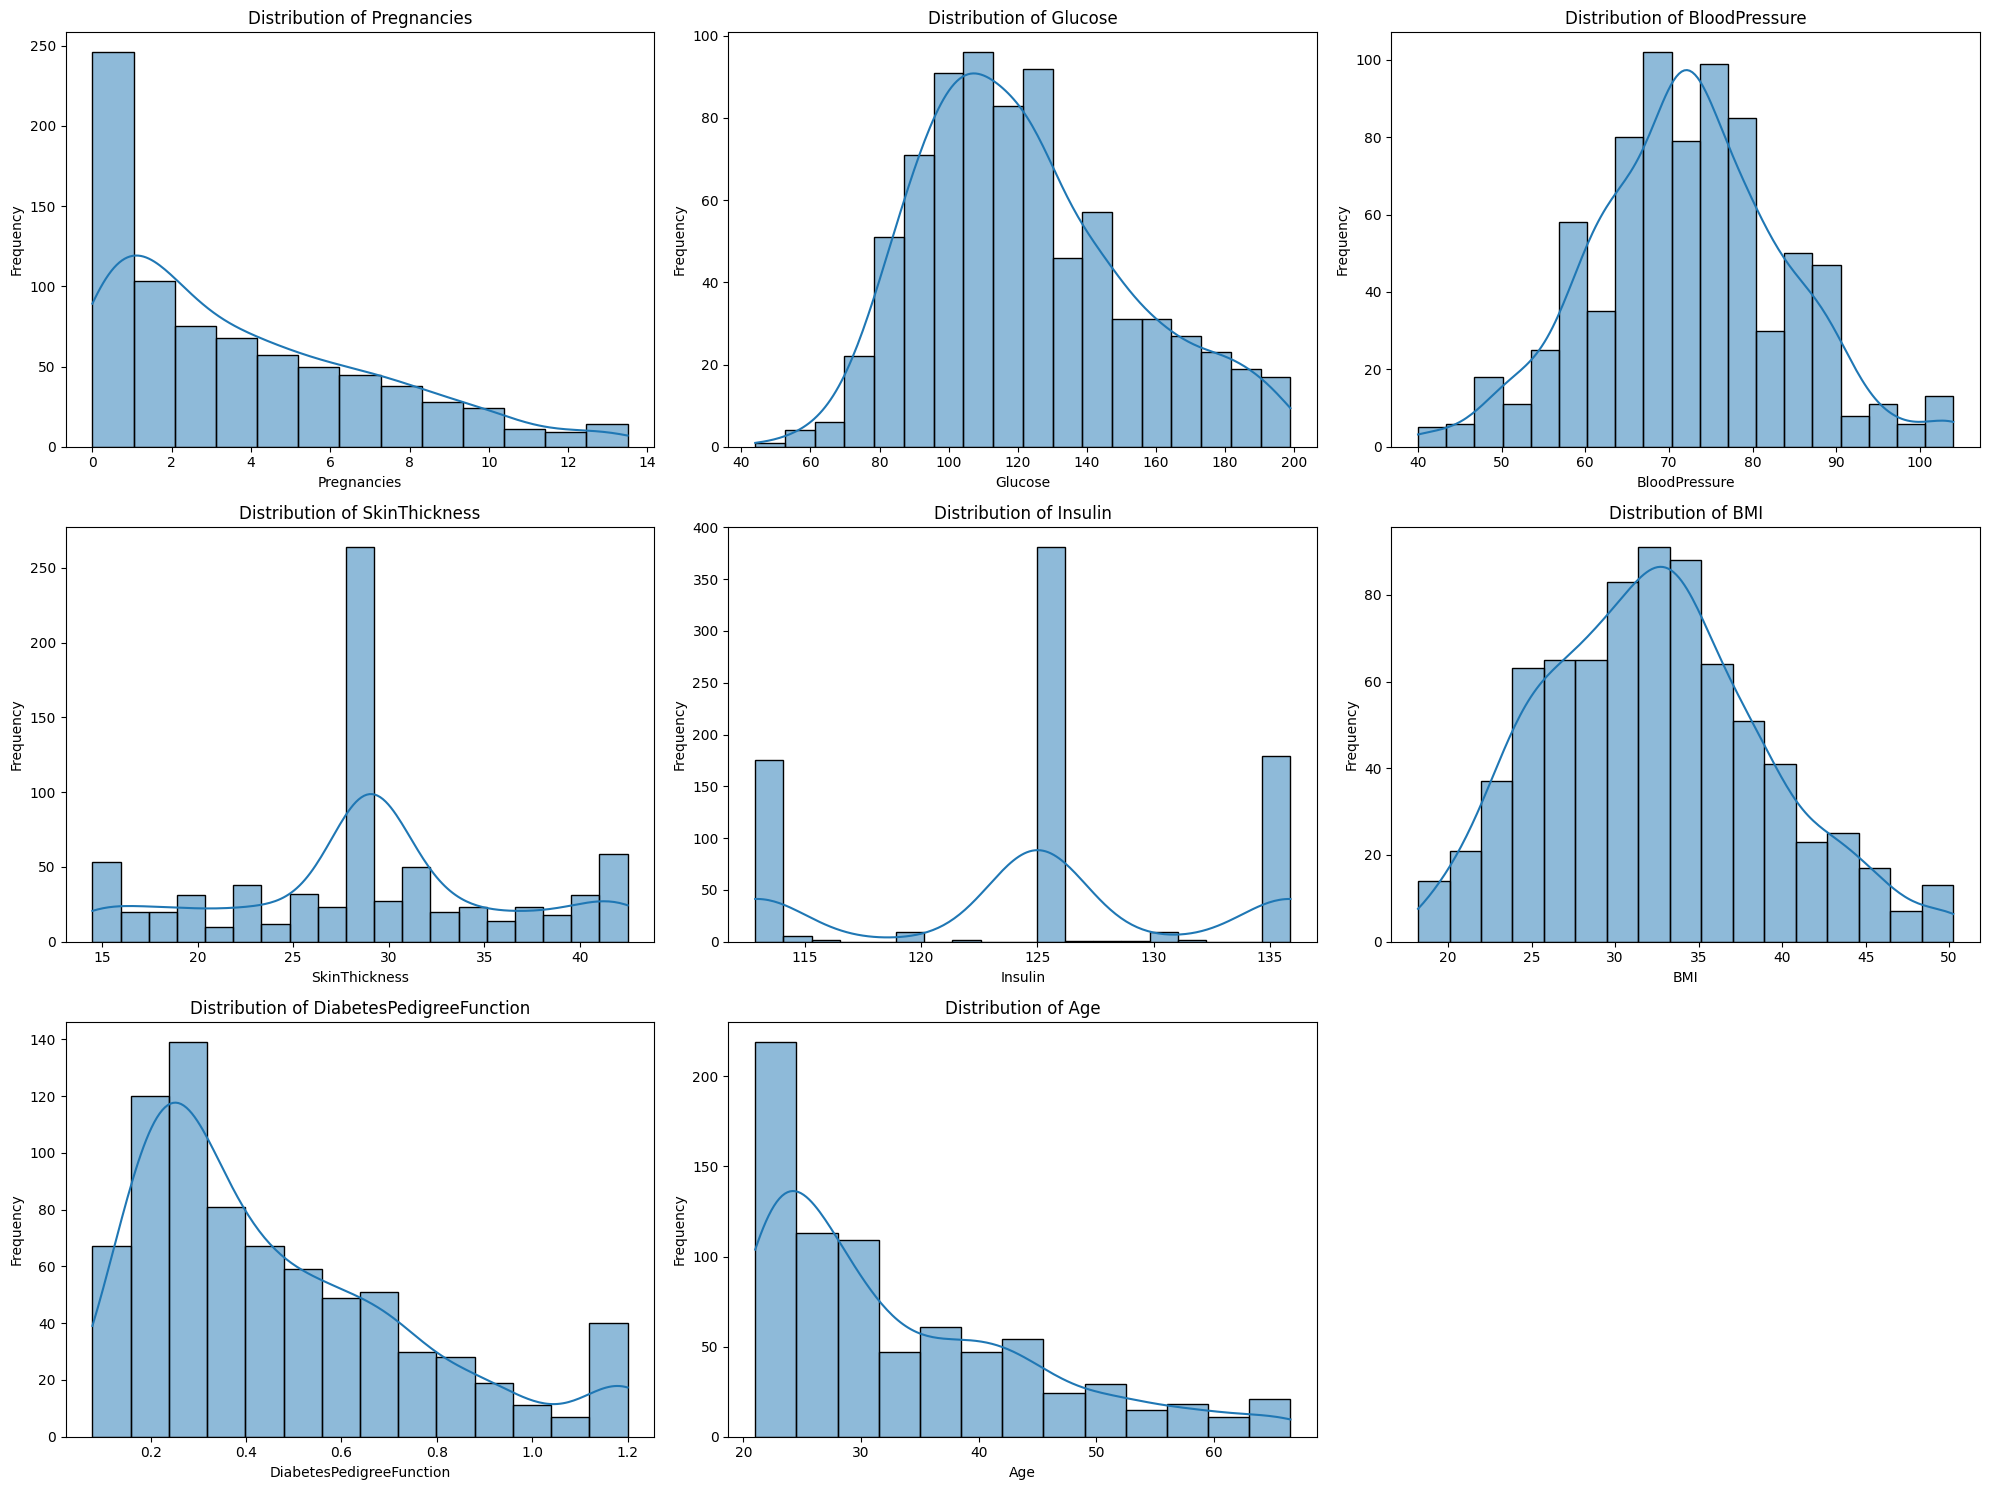

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=df, hue='Outcome', palette='viridis', legend=False)
plt.title('Distribution of Diabetes Outcome')
plt.xlabel('Outcome (0: Non-Diabetic, 1: Diabetic)')
plt.ylabel('Count')
plt.show()

# Create histograms for all numerical features
plt.figure(figsize=(20, 15))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

To further explore the relationship between each numerical feature and the 'Outcome', I will create violin plots. These plots combine aspects of box plots and kernel density plots, showing both the distribution and central tendencies for each outcome group.

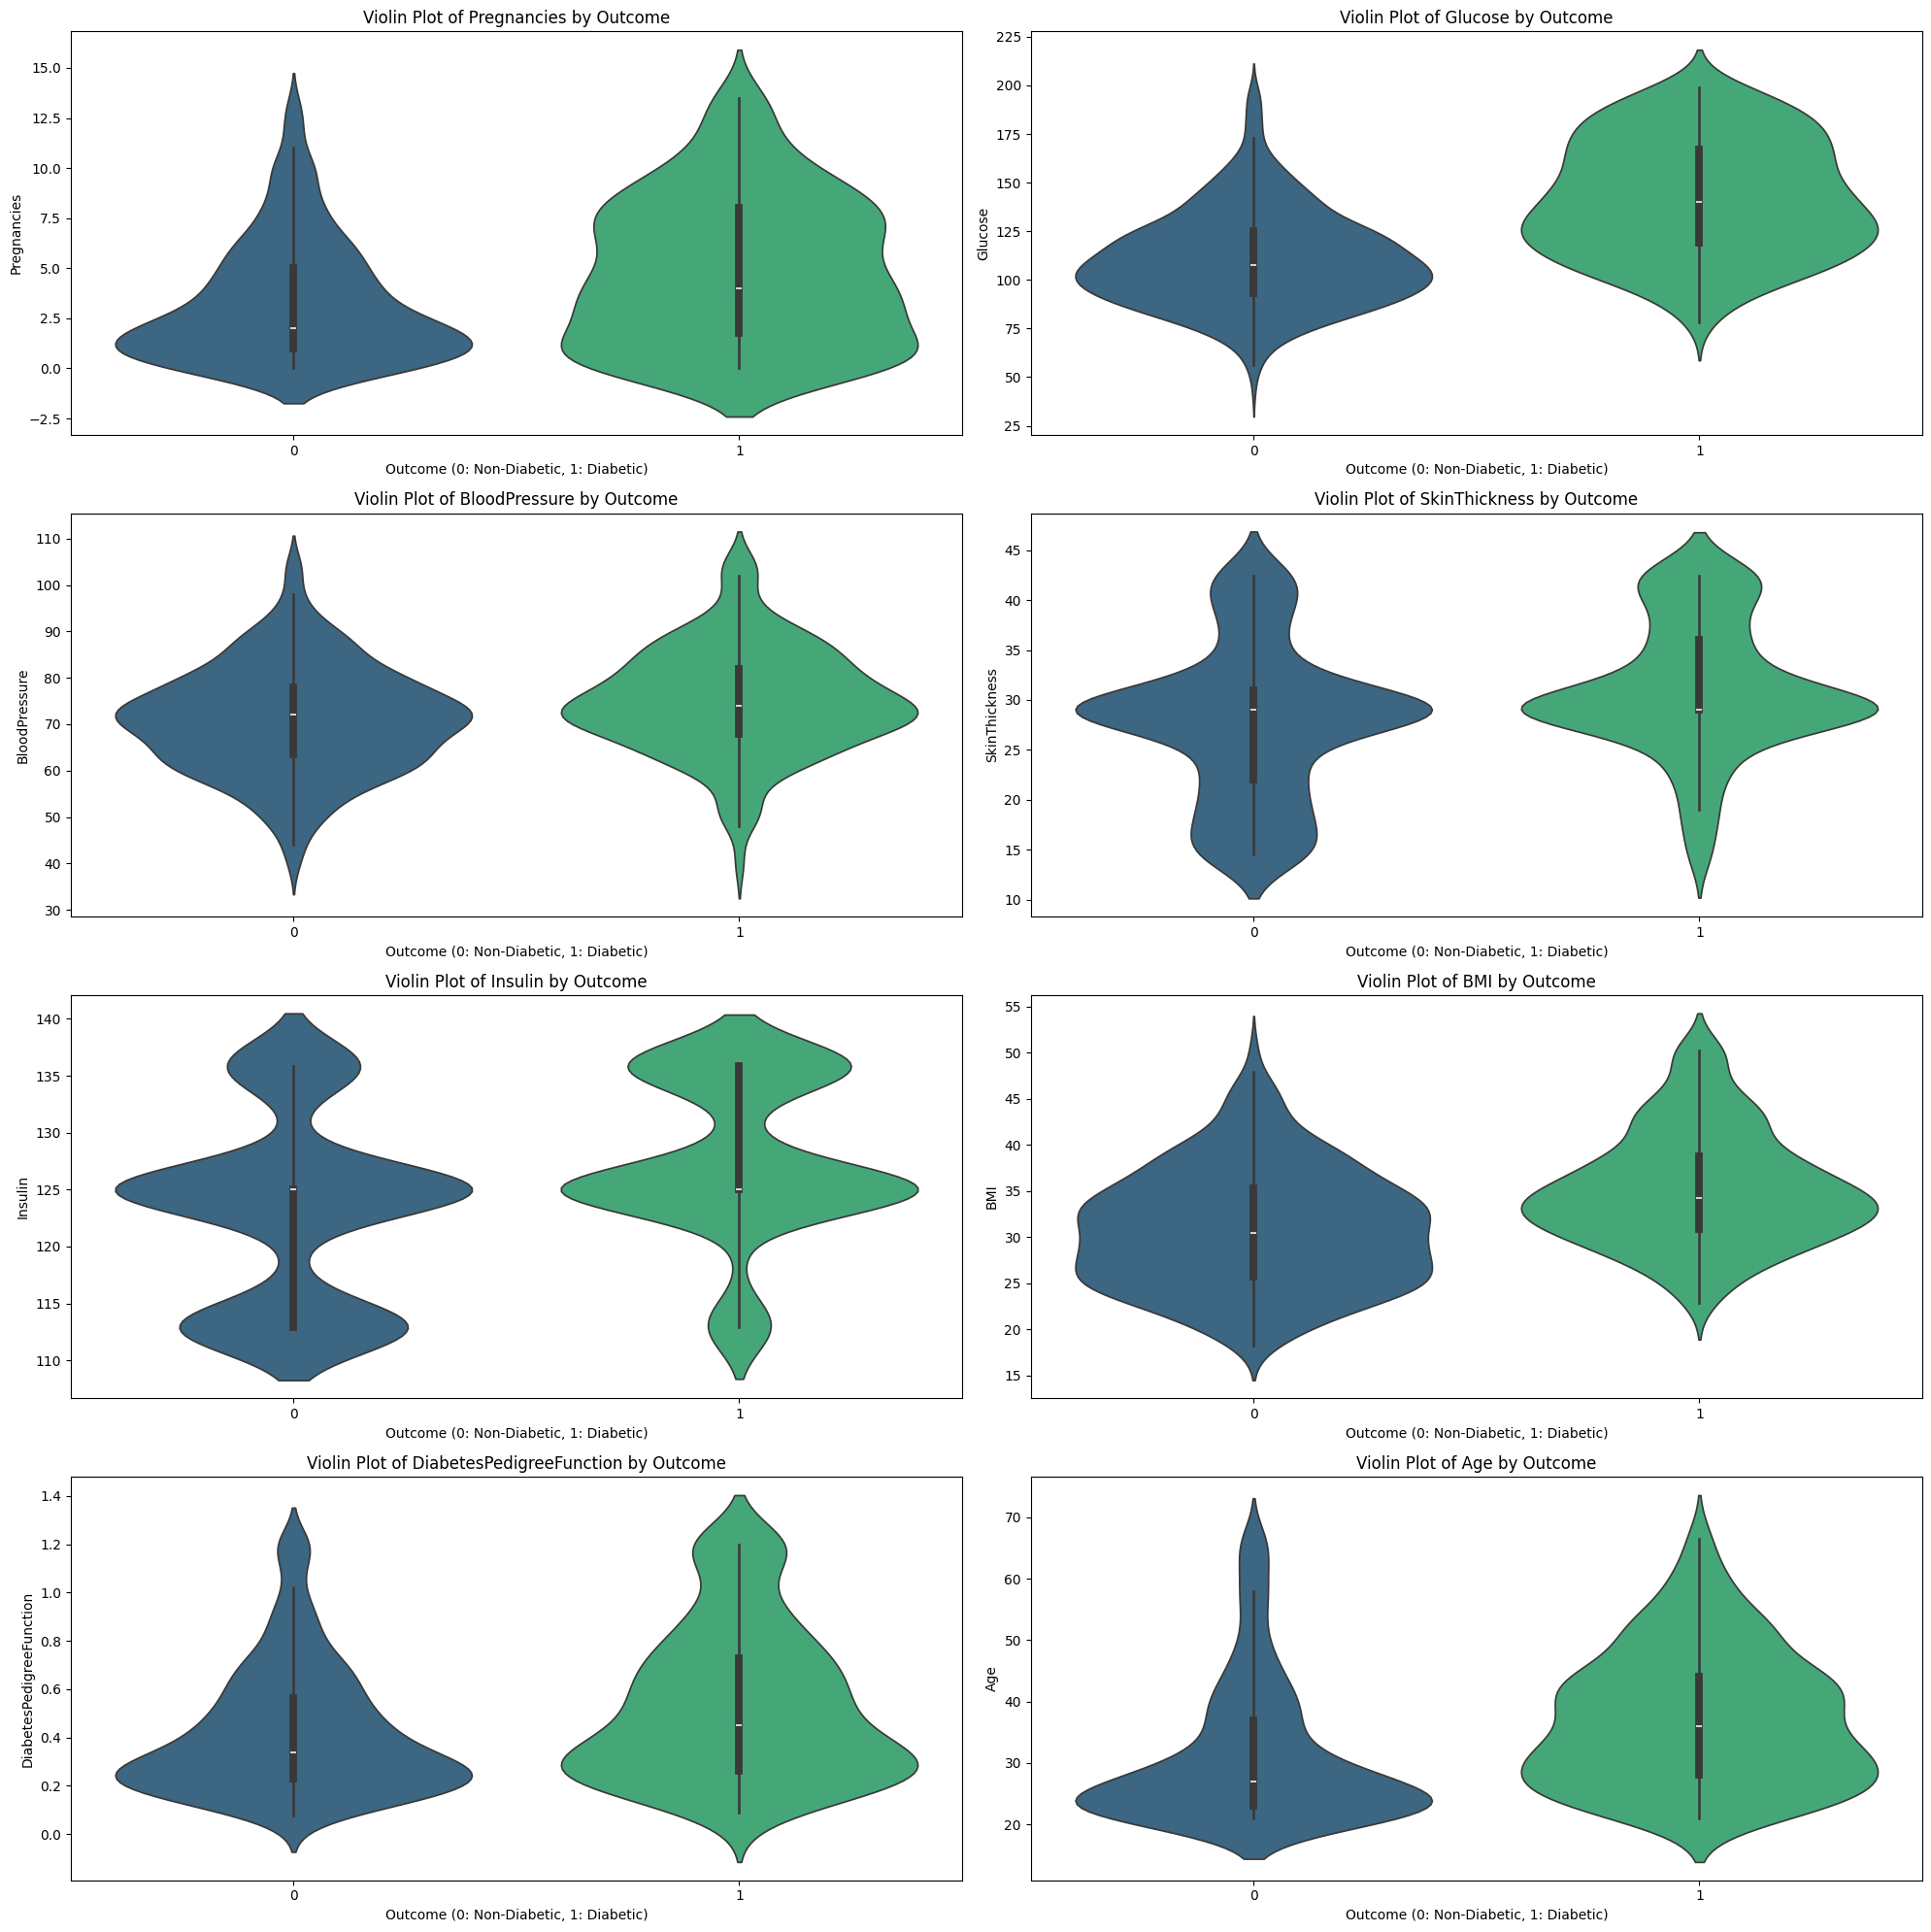

In [ ]:
plt.figure(figsize=(20, 20))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 2, i + 1) # Adjust subplot grid as needed
    sns.violinplot(x='Outcome', y=col, data=df, hue='Outcome', palette='viridis', legend=False)
    plt.title(f'Violin Plot of {col} by Outcome')
    plt.xlabel('Outcome (0: Non-Diabetic, 1: Diabetic)')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

Finally for the EDA section, I will use a `pairplot` to visualize the pairwise relationships and distributions of all numerical features, colored by the target variable 'Outcome'. This provides a comprehensive overview of how features interact with each other and how they separate the two outcome classes.

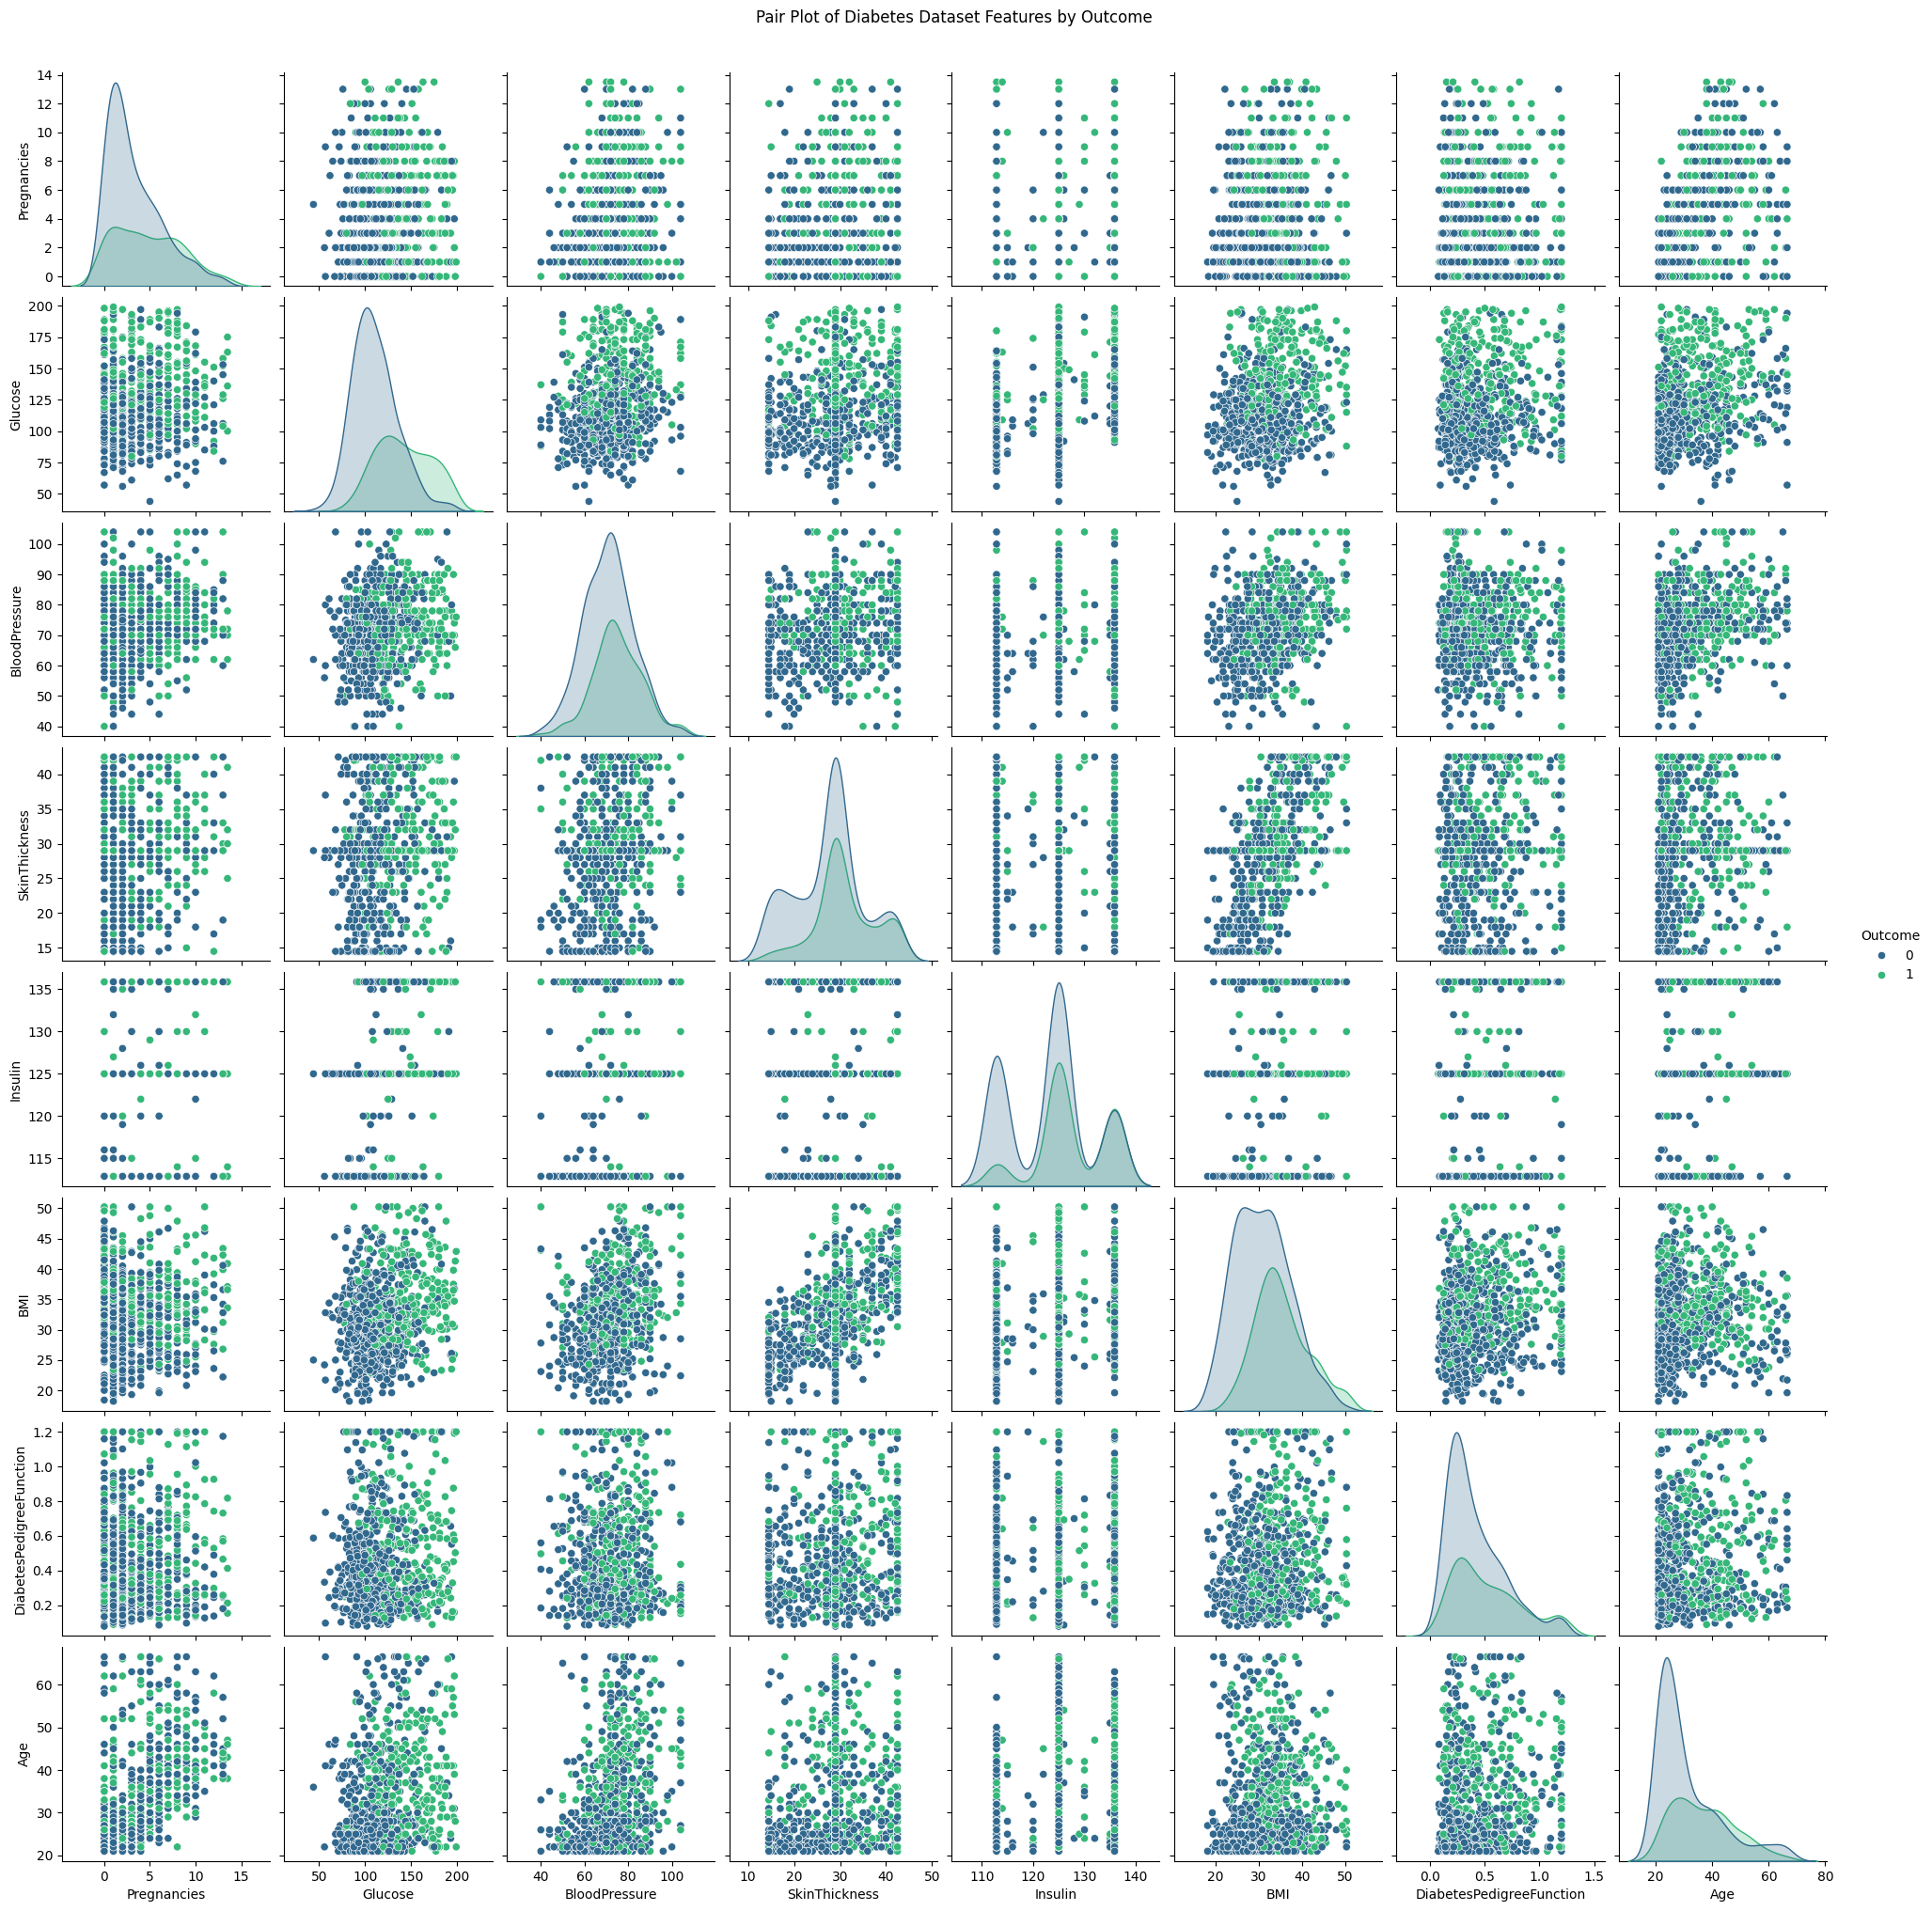

In [ ]:
sns.pairplot(df, hue='Outcome', palette='viridis', diag_kind='kde')
plt.suptitle('Pair Plot of Diabetes Dataset Features by Outcome', y=1.02) # Adjust title position
plt.show()

## Visualize Key Features

### Subtask:
Create visualizations to better understand the distribution and relationships of important variables in the `diabetes.csv` dataset. For example, visualize patient demographics, glucose levels, or insulin levels. Ensure all plots have legends for clarity.

I will create a scatter plot of 'Glucose' versus 'Insulin', colored by 'Outcome'. This will help visualize the relationship between these two critical features in diabetes and how they differ between diabetic and non-diabetic individuals.

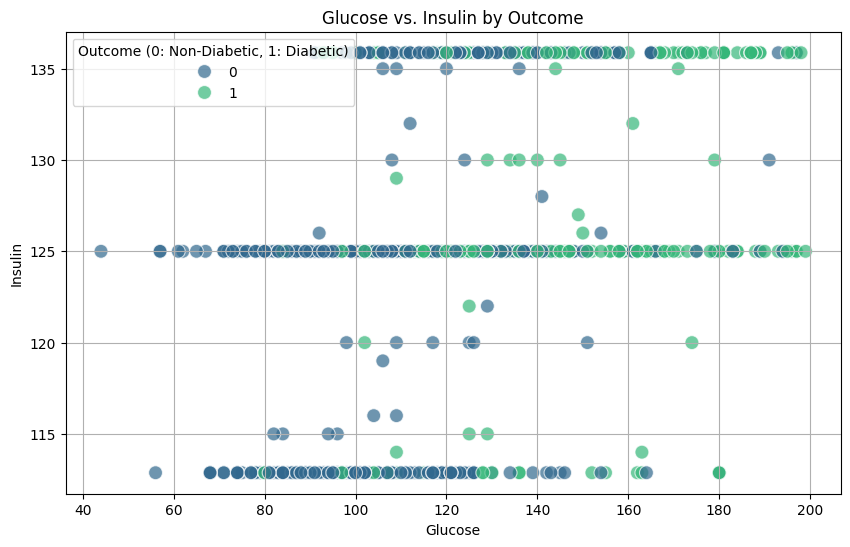

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Glucose', y='Insulin', hue='Outcome', data=df, palette='viridis', s=100, alpha=0.7)
plt.title('Glucose vs. Insulin by Outcome')
plt.xlabel('Glucose')
plt.ylabel('Insulin')
plt.legend(title='Outcome (0: Non-Diabetic, 1: Diabetic)')
plt.grid(True)
plt.show()

Next, I will create a scatter plot of 'BMI' versus 'Age', colored by 'Outcome'. This visualization helps understand the interplay between these two demographic and physiological factors in relation to diabetes diagnosis.

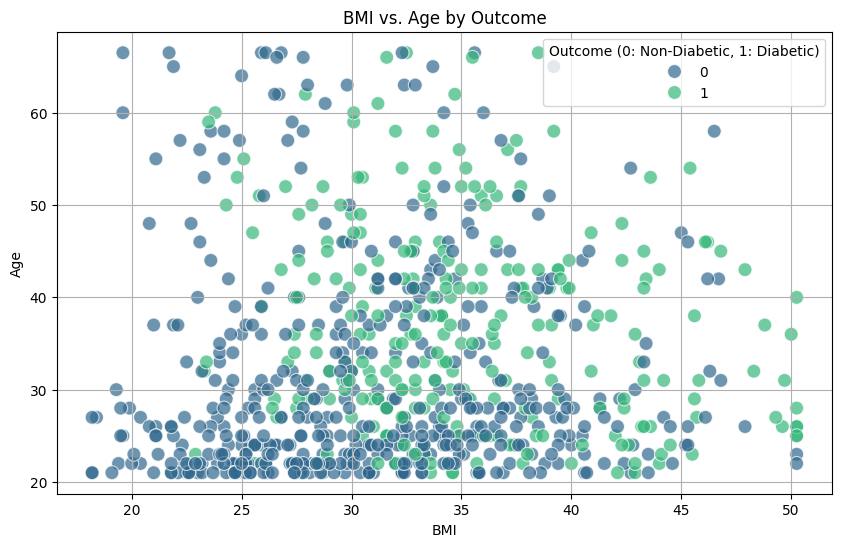

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='BMI', y='Age', hue='Outcome', data=df, palette='viridis', s=100, alpha=0.7)
plt.title('BMI vs. Age by Outcome')
plt.xlabel('BMI')
plt.ylabel('Age')
plt.legend(title='Outcome (0: Non-Diabetic, 1: Diabetic)')
plt.grid(True)
plt.show()

To assess if the number of pregnancies is a distinguishing factor, I will create a grouped bar plot showing the average number of pregnancies for diabetic and non-diabetic individuals.

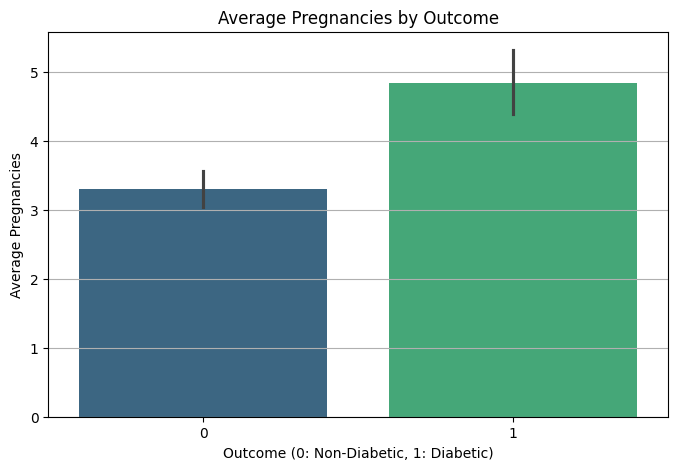

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Outcome', y='Pregnancies', data=df, hue='Outcome', palette='viridis', legend=False)
plt.title('Average Pregnancies by Outcome')
plt.xlabel('Outcome (0: Non-Diabetic, 1: Diabetic)')
plt.ylabel('Average Pregnancies')
plt.grid(axis='y')
plt.show()

Finally, I will create a histogram of 'Age' for both diabetic and non-diabetic individuals to visualize and compare their age distributions. This will help understand if certain age groups are more prone to diabetes.

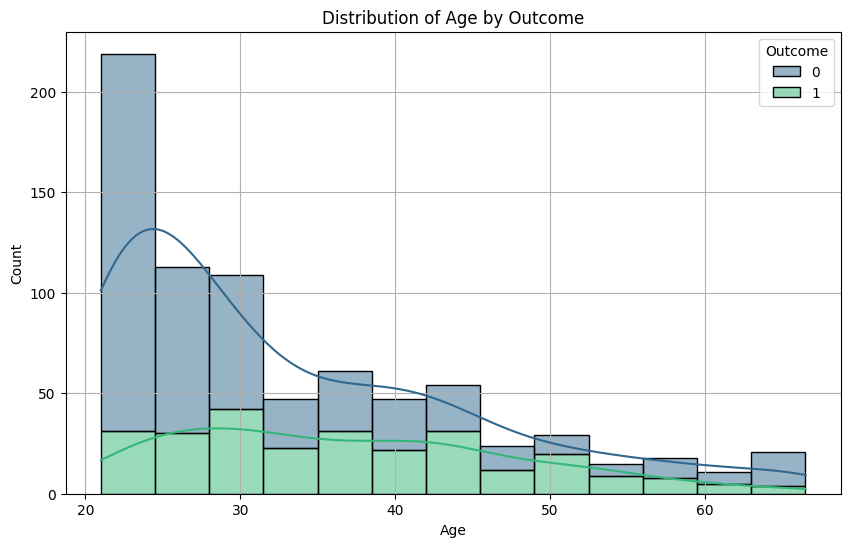

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', hue='Outcome', multiple='stack', kde=True, palette='viridis')
plt.title('Distribution of Age by Outcome')
plt.xlabel('Age')
plt.ylabel('Count')
plt.grid(True)
plt.show()

### Comparison of Insulin Distribution (Original vs. Imputed)

### Statistical Significance Testing (P-values)

To formally assess if there are statistically significant differences between the diabetic (Outcome=1) and non-diabetic (Outcome=0) groups for each numerical feature, I will conduct independent samples t-tests. The p-value from these tests will indicate the probability of observing such a difference by chance if there were no true difference between the groups.

In [22]:
from scipy import stats
import pandas as pd

# Separate the data into two groups based on the 'Outcome' variable
df_non_diabetic = df[df['Outcome'] == 0]
df_diabetic = df[df['Outcome'] == 1]

# Prepare a list to store the results
p_value_results = []

# Perform independent t-tests for each numerical column
for col in numerical_cols:
    # Only perform t-test if both groups have data for the column
    if not df_non_diabetic[col].empty and not df_diabetic[col].empty:
        # Levene's test for equality of variances
        # If p-value of Levene's test is < 0.05, assume unequal variances (False)
        # Otherwise, assume equal variances (True)
        stat_levene, p_levene = stats.levene(df_non_diabetic[col], df_diabetic[col])
        equal_var = p_levene > 0.05

        # Perform independent t-test
        stat, p_value = stats.ttest_ind(df_non_diabetic[col], df_diabetic[col], equal_var=equal_var)
        p_value_results.append({'Feature': col, 'P-value': p_value})
    else:
        p_value_results.append({'Feature': col, 'P-value': 'Not enough data in one or both groups'})

# Display the p-values in a DataFrame for better readability
p_value_df = pd.DataFrame(p_value_results)
display(p_value_df.round(4))

print("\nInterpretation: A p-value less than a chosen significance level (e.g., 0.05) suggests a statistically significant difference between the means of the two groups for that feature.")

,Feature,P-value
0,Pregnancies,0.0000
1,Glucose,0.0000
2,BloodPressure,0.0715
3,SkinThickness,0.0494
4,Insulin,0.0010
5,BMI,0.0000
6,DiabetesPedigreeFunction,0.0000
7,Age,0.0000



Interpretation: A p-value less than a chosen significance level (e.g., 0.05) suggests a statistically significant difference between the means of the two groups for that feature.


## Final Task

### Subtask:
Summarize the initial findings from the data loading, cleaning, and exploratory analysis steps for the `diabetes.csv` dataset, and suggest potential next steps for deeper analysis or modeling based on these insights.

### Summary of Findings

**Data Loading and Initial Structure**:
- The `diabetes.csv` dataset contains 768 rows and 9 columns.
- Initial inspection showed no explicit missing values, but several columns (`Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`) contained biologically implausible zero values, indicating missing data.

**Data Cleaning and Preprocessing**:
- Implicit zero values in `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` were successfully replaced with `NaN` and then imputed using the median of their respective columns. This significantly improved the data quality and robustness.
- Outliers in numerical features were identified through box plots and addressed by capping them using the Interquartile Range (IQR) method, leading to more realistic data distributions.

**Exploratory Data Analysis (EDA)**:
- **Correlation Analysis**: The heatmap revealed strong positive correlations between `Glucose` and `Outcome` (~0.49), `BMI` and `Outcome` (~0.31), and `Insulin` and `Outcome` (~0.27). `Pregnancies` and `Age` also showed moderate positive correlations with `Outcome`.
- **Feature Distributions**: Histograms and violin plots provided insights into the distributions of individual features and how they vary across diabetic and non-diabetic groups. For instance, higher values in `Glucose`, `BMI`, and `Insulin` were generally associated with a positive diabetes `Outcome`.
- **Target Variable Distribution**: The count plot showed the imbalance in the target variable, with more non-diabetic individuals than diabetic ones.

**Key Feature Visualizations**:
- **Glucose vs. Insulin**: Diabetic individuals generally exhibited higher glucose and insulin levels.
- **BMI vs. Age**: While there wasn't a clear linear separation, higher BMI and older age groups showed a tendency towards diabetes.
- **Average Pregnancies**: The average number of pregnancies was slightly higher for diabetic individuals.
- **Age Distribution**: The distribution of age for diabetic individuals appeared shifted towards older age groups compared to non-diabetic individuals.

### Suggested Next Steps

1.  **Feature Engineering**: Explore creating new features such as age categories, BMI categories, or interaction terms between highly correlated features (e.g., Glucose-Insulin interaction) to potentially improve model performance.
2.  **Addressing Class Imbalance**: Given the imbalance in the `Outcome` variable, consider techniques like oversampling (e.g., SMOTE) or undersampling, or using algorithms robust to imbalance, when building predictive models.
3.  **Model Building**: Train various machine learning classification models (e.g., Logistic Regression, Support Vector Machines, Random Forest, Gradient Boosting) to predict diabetes based on the cleaned and preprocessed data.
4.  **Model Evaluation and Hyperparameter Tuning**: Evaluate model performance using appropriate metrics (e.g., accuracy, precision, recall, F1-score, ROC AUC) and use techniques like cross-validation and hyperparameter tuning to optimize model performance.
5.  **Further Investigation**: Conduct deeper statistical tests to confirm the significance of observed differences between diabetic and non-diabetic groups for various features.

# Task
Perform a comprehensive analysis of the `diabetes.csv` dataset. This involves loading the data, understanding its structure, cleaning and preprocessing it by handling missing values and outliers, conducting exploratory data analysis to uncover patterns and relationships, visualizing key features, and finally summarizing the findings with suggested next steps for deeper analysis or modeling.

## Load Data

### Subtask:
Load the 'diabetes.csv' dataset into a pandas DataFrame.


## Data Overview

### Subtask:
Display the first few rows, check data types, and get a summary of basic statistics for initial understanding.


# Task
Perform a comprehensive analysis of the `diabetes.csv` dataset. This involves loading the data, understanding its structure, cleaning and preprocessing it by handling missing values and outliers, conducting exploratory data analysis to uncover patterns and relationships, visualizing key features, and finally summarizing the findings with suggested next steps for deeper analysis or modeling.

## Load Data

### Subtask:
Load the 'diabetes.csv' dataset into a pandas DataFrame.
